In [1]:
#!/usr/bin/env python3
"""
This script compares the standard deviation (STD) of corrections for interferograms.
Author: Muhammet Nergizci
"""

#%% Import
import getopt
import os
import sys
import time
import shutil
import glob
import numpy as np
from osgeo import gdal
import multiprocessing as multi
import matplotlib.pyplot as plt
from lics_unwrap import load_tif2xr


setting pyproj data directory


In [3]:
filepath='/work/scratch-pw2/licsar/mnergiz/nosetnoiono/021D_05266_252525/GEOC/20221212_20221224'
filepath='/work/scratch-pw2/licsar/mnergiz/nosetnoiono/116A_05207_252525/GEOC/20210427_20210521'
rawfile=os.path.join(filepath, '20210427_20210521.geo.sbovldiff.adf.mm.tif.prelb.tif')
corfile=os.path.join(filepath, '20210427_20210521.geo.sbovldiff.adf.mm.notides.noiono.tif')

In [14]:
rawdata = load_tif2xr(rawfile)
corrected_data = load_tif2xr(corfile)

std_unw = np.nanstd(rawdata.values)
std_unwcor = np.nanstd(corrected_data.values)
rate = (std_unw - std_unwcor) / std_unw * 100

In [17]:
std_unw

107.55204

In [16]:
std_unwcor

105.96178

In [15]:
rate

1.4785918407142162

In [7]:
rawdata-corrected_data

<xarray.DataArray (lat: 4683, lon: 3879)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ..., 
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], dtype=float32)
Coordinates:
  * lon          (lon) float64 36.05 36.05 36.05 36.06 ... 39.93 39.93 39.93
  * lat          (lat) float64 40.26 40.26 40.25 40.25 ... 35.58 35.58 35.57
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [11]:
import xarray as xr
cycle=75
aa=np.angle(np.exp(1j * rawdata.values / cycle) * cycle)
rawdata2 = xr.zeros_like(rawdata) 
rawdata2.values=aa

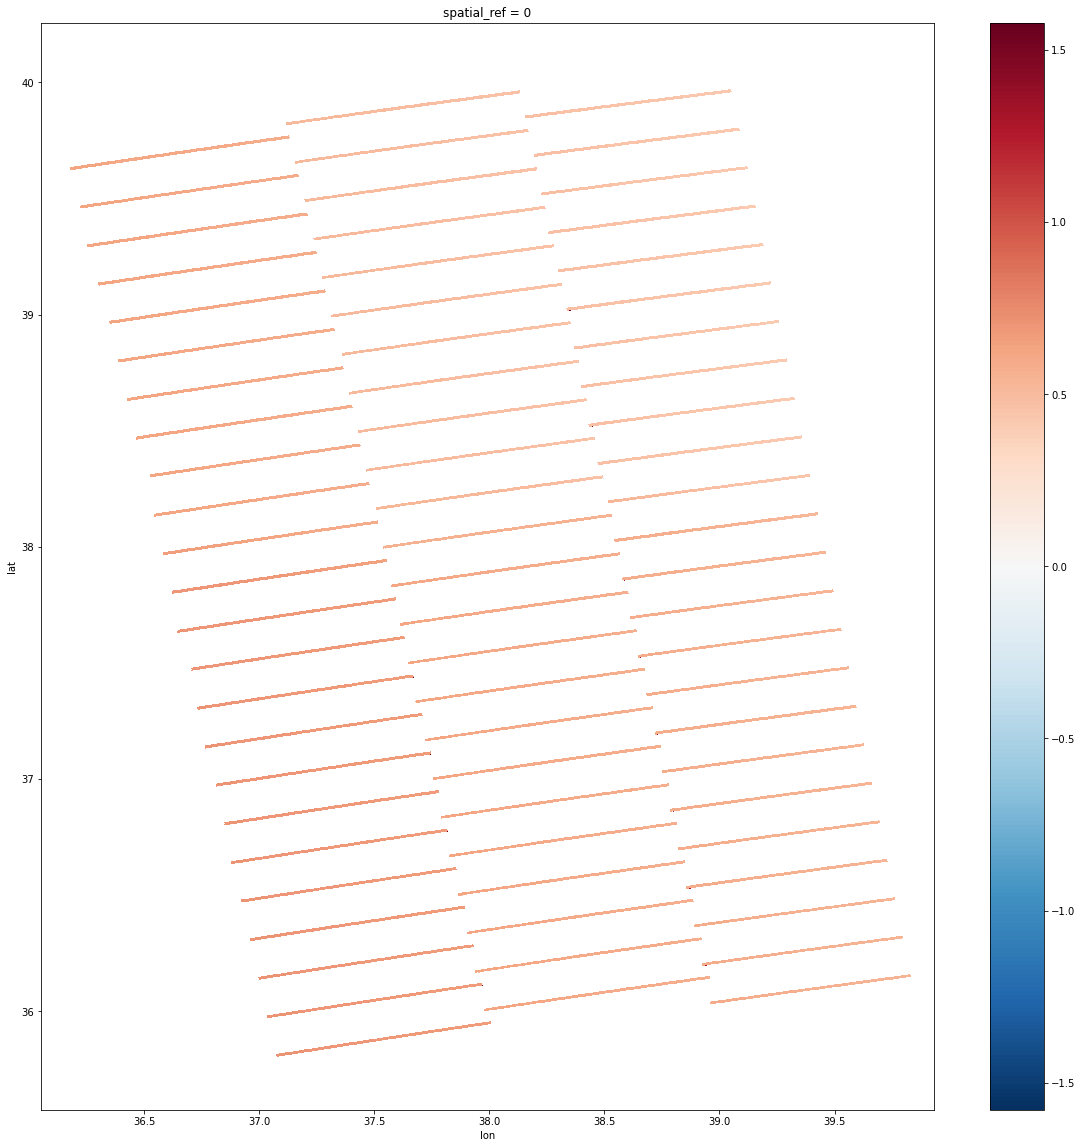

In [25]:
cycle=75
bb=np.angle(np.exp(1j * (corrected_data-rawdata).values / cycle) * cycle)
corrected_data2 = xr.zeros_like(corrected_data)
corrected_data2.values=bb
corrected_data2.plot(figsize=(20,20))

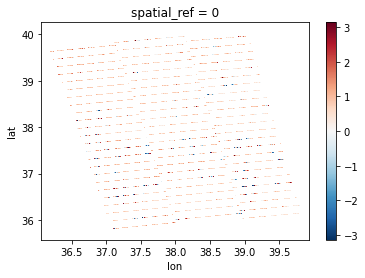

In [20]:
corrected_data2.plot()

In [18]:
std_unw = np.nanstd(rawdata2.values)
std_unwcor = np.nanstd(corrected_data2.values)
rate = (std_unw - std_unwcor) / std_unw * 100
print(std_unw, std_unwcor, rate)

0.679558 0.697909 -2.70051546395


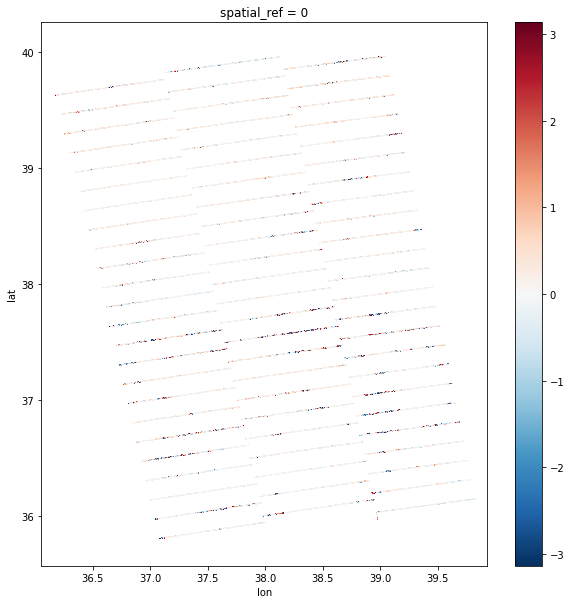

In [12]:
rawdata2.plot(figsize=(10,10))

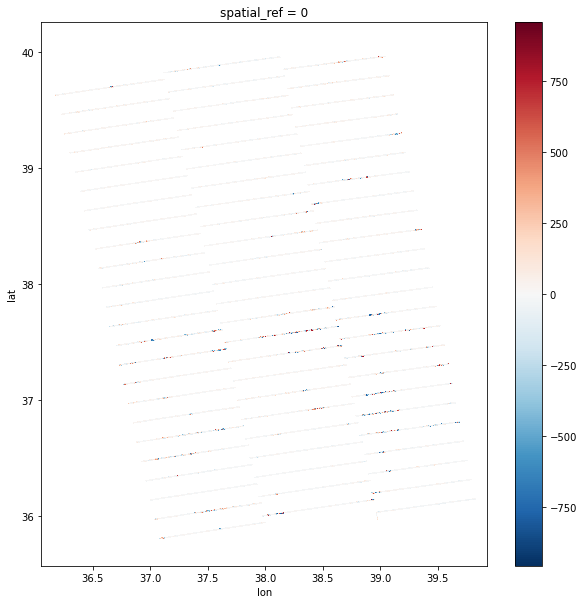

In [8]:
rawdata.plot(figsize=(10,10))

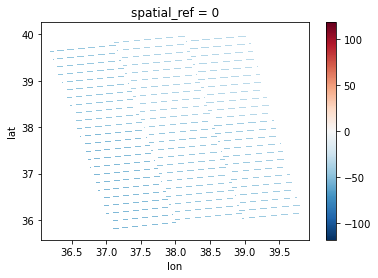

In [6]:
(rawdata-corrected_data).plot()

In [1]:
in_dir1

NameError: name 'in_dir1' is not defined

In [7]:
import os
in_dir1='a'
ifgd='b'
datatype='sbovl'
if datatype == 'unw':
    extofproc = '.geo.unw.tif'
    cycle = 3
    # Define extx if needed for 'unw'
elif datatype == 'sbovl':
    extofproc = '.geo.sbovldiff.adf.mm'
    extofproc2 = '.geo.bovldiff.adf.mm'
    exty = '.tif.prelb.tif'
    extx = ['.notides.noiono.tif', '.notides.tif', '.noiono.tif']
    cycle = 75
else:
    print(f"Unsupported datatype: {datatype}")
        

results = []
for correction in extx:
    unwfile = os.path.join(in_dir1, ifgd + extofproc + exty)
    if not os.path.exists(unwfile):
        unwfile = os.path.join(in_dir1, ifgd + extofproc2 + exty)
    unw_corfile = os.path.join(in_dir1, ifgd + extofproc + correction)
    print(unwfile, unw_corfile)    

a/b.geo.bovldiff.adf.mm.tif.prelb.tif a/b.geo.sbovldiff.adf.mm.notides.noiono.tif
a/b.geo.bovldiff.adf.mm.tif.prelb.tif a/b.geo.sbovldiff.adf.mm.notides.tif
a/b.geo.bovldiff.adf.mm.tif.prelb.tif a/b.geo.sbovldiff.adf.mm.noiono.tif


In [6]:
unwfile

'a/b.geo.bovldiff.adf.mm.tif.prelb.tif'

In [18]:
# Replace 0 with NaN in the DataArray 'rawdata'
rawdata = rawdata.where(rawdata != 0, np.nan)
corrected_data = corrected_data.where(corrected_data != 0, np.nan)

In [19]:
rawdata

<xarray.DataArray (lat: 4683, lon: 3879)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ..., 
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], dtype=float32)
Coordinates:
  * lon          (lon) float64 36.05 36.05 36.05 36.06 ... 39.93 39.93 39.93
  * lat          (lat) float64 40.26 40.26 40.25 40.25 ... 35.58 35.58 35.57
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [20]:
std_unw = np.nanstd(rawdata.values)
std_unw

107.55204

In [12]:
std_unw

107.55204

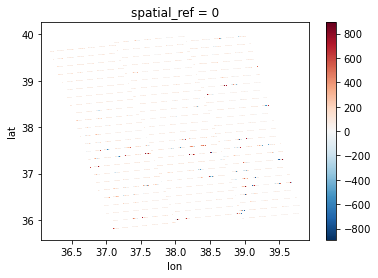

In [16]:
corrected_data.plot()

In [13]:
std_unwcor = np.nanstd(corrected_data.values)

In [14]:
std_unwcor

105.96178

In [ ]:
class Usage(Exception):
    """Usage context manager"""
    def __init__(self, msg):
        self.msg = msg

#%% Main
def main(argv=None):
    if argv is None:
        argv = sys.argv

    start = time.time()
    global in_dir, cycle, cmap_wrap, datatype, ifgdates
    
    # Default parameters
    in_dir = ""
    datatype = 'sbovl'
    
    try:
        n_para = len(os.sched_getaffinity(0))
    except:
        n_para = multi.cpu_count()
    
    q = multi.get_context('fork')
    cmap_wrap = cmc.romaO  # Colormap for visualization

    #%% Read options
    try:
        opts, args = getopt.getopt(argv[1:], "hi:", ["help", "datatype=", "n_para="])
        for o, a in opts:
            if o in ('-h', '--help'):
                print(__doc__)
                return 0
            elif o == '-i':
                in_dir = a
            elif o == '--datatype':
                datatype = a
            elif o == '--n_para':
                n_para = int(a)
    
        if not in_dir:
            raise Usage('No input directory given, -i is not optional!')
        if not os.path.isdir(in_dir):
            raise Usage(f'No {in_dir} directory exists!')
        if len(os.listdir(in_dir)) == 0:
            raise Usage(f'Directory {in_dir} is empty, cancelling.')
    
    except Usage as err:
        print(f"\nERROR: {err.msg}\nFor help, use -h or --help.\n", file=sys.stderr)
        return 2

    #%% Read data information
    in_dir = os.path.abspath(in_dir)
    ifgdates = tools_lib.get_ifgdates(in_dir)
    n_ifg = len(ifgdates)
    
    print('\nChecking the STD variation...', flush=True)
    
    #%% Process interferograms with parallel execution
    if n_ifg > 0:
        _n_para = min(n_para, n_ifg)  # Avoid excess threads
        print(f'  {_n_para} parallel processing...', flush=True)
        
        with q.Pool(_n_para) as p:
            _return = p.starmap(correct_wrapper, [(i, datatype) for i in range(n_ifg)])
        
        for correction in ['.notides.noiono']: #'.noiono', '.notides', 
            correction_info_file = os.path.join(in_dir, f'correction_info{correction}.txt')
            with open(correction_info_file, "w") as f:
                print('Displacement STD (mm) Before After ReductionRate', file=f)
                for result in _return:
                    for res in result:
                        if res[0] == 2 and res[2] == f'{correction}.tif':
                            print('{0}  {1:.4f}  {2:.4f} {3:.1f}%'.format(*res[1]), file=f)
    
    print("", flush=True)
    
    #%% Finish execution
    elapsed_time = time.time() - start
    print(f"\nElapsed time: {int(elapsed_time//3600):02}h {int((elapsed_time//60)%60):02}m {int(elapsed_time%60):02}s")
    print(f'\n{os.path.basename(argv[0])} Successfully finished!')

#%% Correction function
def correct_wrapper(i, datatype='sbovl'):
    global ifgdates
    ifgd = ifgdates[i]
    if i % 10 == 0:
        print(f'  Finished {i}/{len(ifgdates)}th interferogram...', flush=True)
    
    in_dir1 = os.path.join(in_dir, ifgd)
    
    if datatype == 'unw':
        extofproc = '.geo.unw.tif'
        cycle = 3
    elif datatype == 'sbovl':
        extofproc = '.geo.sbovldiff.adf.mm'
        extofproc2 = '.geo.bovldiff.adf.mm'
        exty = '.tif.prelb.tif'
        extx = ['.notides.noiono.tif'] #'.noiono.tif', '.notides.tif', 
        cycle = 75
    else:
        print(f"Unsupported datatype: {datatype}")
        return 1, ifgd
    
    results = []
    for correction in extx:
        unwfile = os.path.join(in_dir1, ifgd + extofproc + exty)
        if not os.path.exists(unwfile):
            unwfile = os.path.join(in_dir1, ifgd + extofproc2 + exty)
        if not os.path.exists(unwfile):
            print(f"{ifgd} does not exist! Skipping")
            continue
        
        unw_corfile = os.path.join(in_dir1, ifgd + extofproc + correction)
        if not os.path.exists(unw_corfile):
            print(f"Correction file {unw_corfile} missing! Skipping")
            continue
        
        rawdata = load_tif2xr(unwfile)
        corrected_data = load_tif2xr(unw_corfile)
        
        std_unw = np.nanstd(rawdata.values)
        std_unwcor = np.nanstd(corrected_data.values)
        rate = (std_unw - std_unwcor) / std_unw * 100
        
        results.append((2, [ifgd, std_unw, std_unwcor, rate], correction))
    
    return results if results else [(1, ifgd, None)]

#%% Run script
if __name__ == "__main__":
    sys.exit(main())


In [26]:
import h5py
filepath='/work/scratch-pw2/licsar/mnergiz/nosetnoiono/021D_05266_252525/TS_GEOCml10/cum.h5'
# Open the file in read mode ('r')
with h5py.File(filepath, "r") as f:
    print("Available datasets:")
    print(list(f.keys()))  # List all datasets in the file


Available datasets:
['E.geo', 'N.geo', 'U.geo', 'bperp', 'coh_avg', 'corner_lat', 'corner_lon', 'cum', 'gap', 'hgt', 'imdates', 'maxTlen', 'n_gap', 'n_ifg_noloop', 'n_unw', 'post_lat', 'post_lon', 'refarea', 'resid_rms', 'slc.mli', 'vel', 'vintercept']


In [12]:
import numpy as np

# Open the HDF5 file
with h5py.File(filepath, "r") as f:
    # Load the 'cum' dataset
    cum = f["cum"][:]
    

In [13]:
cum

array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       ...,

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan

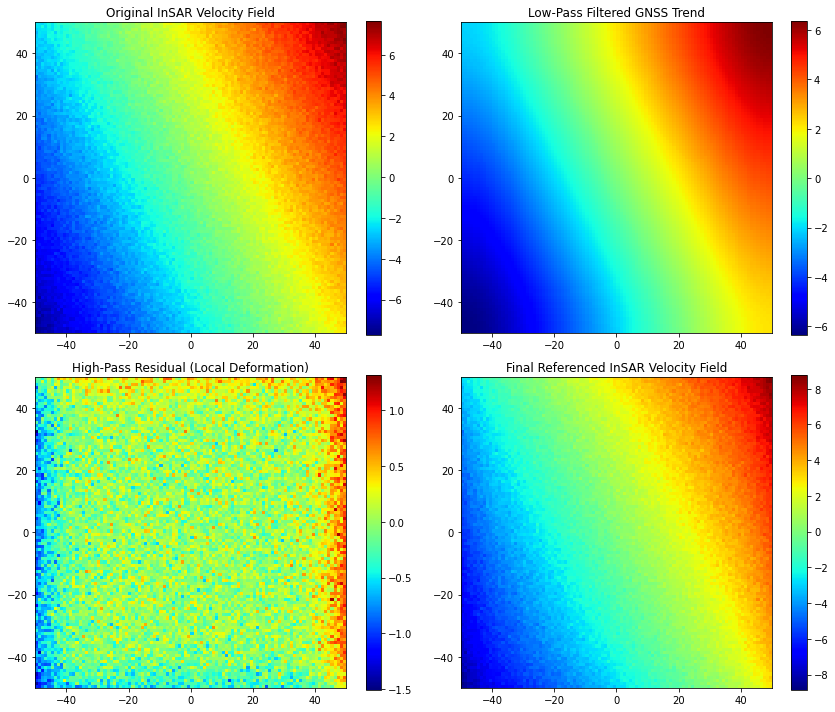

In [27]:
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

# Generate synthetic InSAR velocity field (random noise + large-scale trend)
np.random.seed(42)
x = np.linspace(-50, 50, 100)
y = np.linspace(-50, 50, 100)
X, Y = np.meshgrid(x, y)

# Large-scale tectonic trend (low-frequency signal)
V_GNSS = 0.1 * X + 0.05 * Y  

# Local deformation signal (high-frequency noise)
V_InSAR = V_GNSS + np.random.normal(0, 0.2, size=X.shape)

# Apply a Gaussian low-pass filter to extract the large-scale trend
sigma = 10  # Controls smoothing level
V_LowPass = ndimage.gaussian_filter(V_InSAR, sigma=sigma)

# Compute high-pass residuals (local deformation)
V_HighPass = V_InSAR - V_LowPass

# Final referenced velocity field (adding back GNSS trend)
V_Referenced = V_HighPass + V_GNSS

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
im = ax.imshow(V_InSAR, extent=[-50, 50, -50, 50], cmap="jet", origin="lower")
ax.set_title("Original InSAR Velocity Field")
fig.colorbar(im, ax=ax)

ax = axes[0, 1]
im = ax.imshow(V_LowPass, extent=[-50, 50, -50, 50], cmap="jet", origin="lower")
ax.set_title("Low-Pass Filtered GNSS Trend")
fig.colorbar(im, ax=ax)

ax = axes[1, 0]
im = ax.imshow(V_HighPass, extent=[-50, 50, -50, 50], cmap="jet", origin="lower")
ax.set_title("High-Pass Residual (Local Deformation)")
fig.colorbar(im, ax=ax)

ax = axes[1, 1]
im = ax.imshow(V_Referenced, extent=[-50, 50, -50, 50], cmap="jet", origin="lower")
ax.set_title("Final Referenced InSAR Velocity Field")
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


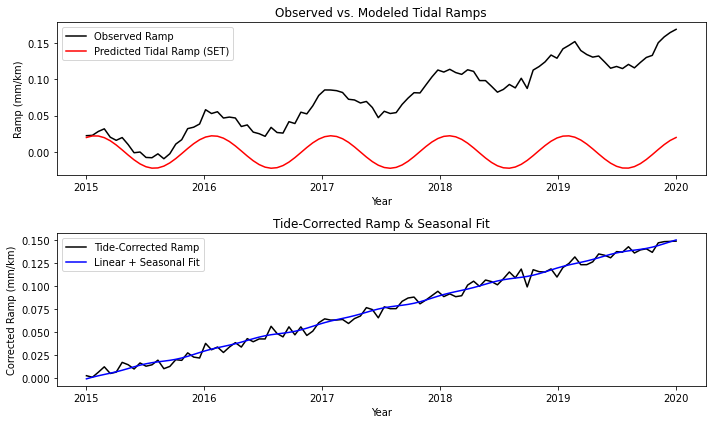

Estimated Ramp Rate (a_dot): 0.0302 mm/km/yr
RMS Error (σ): 0.0044 mm/km


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Simulated dataset: Observed and predicted tidal ramps
np.random.seed(42)
time = np.linspace(2015, 2020, 100)  # Time in years
observed_ramp = 0.03 * (time - 2015) + 0.02 * np.cos(2 * np.pi * time) + 0.01 * np.sin(2 * np.pi * time) + np.random.normal(0, 0.005, len(time))
predicted_tide_ramp = 0.02 * np.cos(2 * np.pi * time) + 0.01 * np.sin(2 * np.pi * time)  # Modelled SET effect

# Compute tide-corrected ramp
tide_corrected_ramp = observed_ramp - predicted_tide_ramp

# Define the linear + seasonal model
def ramp_model(t, a0, a_dot, ac, as_, a2c, a2s):
    return a0 + a_dot * (t - 2015) + ac * np.cos(2 * np.pi * t) + as_ * np.sin(2 * np.pi * t) + a2c * np.cos(4 * np.pi * t) + a2s * np.sin(4 * np.pi * t)

# Fit the model to tide-corrected ramps
params, covariance = curve_fit(ramp_model, time, tide_corrected_ramp)
a0, a_dot, ac, as_, a2c, a2s = params

# Compute fitted values
fitted_ramp = ramp_model(time, *params)

# Compute RMS error (σ)
residuals = tide_corrected_ramp - fitted_ramp
sigma = np.sqrt(np.mean(residuals**2))

# Plot results
plt.figure(figsize=(10, 6))

plt.subplot(2,1,1)
plt.plot(time, observed_ramp, label="Observed Ramp", color='black')
plt.plot(time, predicted_tide_ramp, label="Predicted Tidal Ramp (SET)", color='red')
plt.xlabel("Year")
plt.ylabel("Ramp (mm/km)")
plt.title("Observed vs. Modeled Tidal Ramps")
plt.legend()

plt.subplot(2,1,2)
plt.plot(time, tide_corrected_ramp, label="Tide-Corrected Ramp", color='black')
plt.plot(time, fitted_ramp, label="Linear + Seasonal Fit", color='blue')
plt.xlabel("Year")
plt.ylabel("Corrected Ramp (mm/km)")
plt.title("Tide-Corrected Ramp & Seasonal Fit")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Estimated Ramp Rate (a_dot): {a_dot:.4f} mm/km/yr")
print(f"RMS Error (σ): {sigma:.4f} mm/km")


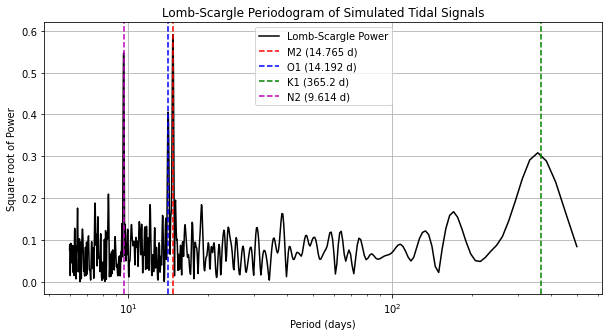